In [1]:
import torch.nn as nn

from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_nd import *

In [2]:
model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 64, 64, 64],
    output_size=1,
    activation=nn.Sigmoid(),
    learning_rate=0.001,
    step_size=1000,
    gamma=0.8,
)

loss_weights = {
    'pde': 1,
    'J2': 10,
    'J3': 1,
    'J4': 1,
}


In [3]:
seeds = [14]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
    model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    model.set_loss_weights(loss_weights)
    early_stopping = EarlyStopping(patience=1000, min_delta=1e-6)
    model.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=1000, alpha=0.9)
    model.save(f'../../models/bs_sobolev_nd/{seed}.pth')

Training model with seed 14...
Iter      0 | Train: 1.4360e+00 | Val: 6.2853e+00 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter    500 | Train: 4.8337e-02 | Val: 1.6420e-01 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter   1000 | Train: 2.2287e-02 | Val: 6.1907e-02 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter   1500 | Train: 1.7026e-02 | Val: 5.0457e-02 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter   2000 | Train: 2.0106e-02 | Val: 4.6259e-02 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter   2500 | Train: 1.2689e-02 | Val: 4.3242e-02 | Weights: pde=0.077  J2=0.769  J3=0.077  J4=0.077
Iter   3000 | Train: 1.0775e-02 | Val: 4.1312e-02 | Weights: pde=0.349  J2=0.093  J3=0.481  J4=0.077
Iter   3500 | Train: 8.5929e-03 | Val: 3.7319e-02 | Weights: pde=0.349  J2=0.093  J3=0.481  J4=0.077
Iter   4000 | Train: 8.9288e-03 | Val: 3.5154e-02 | Weights: pde=0.434  J2=0.266  J3=0.223  J4=0.077
Iter   4500 | Train: 7.8662e-03 | Val: 3.2877e-02 | Weights:

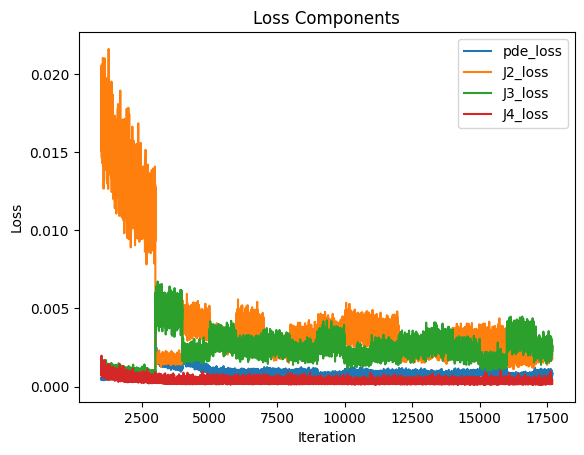

In [4]:
model.plot_losses(detailed=True, start_epoch=1000)